In [7]:
import torch
import torch.nn.functional as F
import numpy as np
from datasets import load_from_disk
from transformers import (
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
)
import json

from transformers.models.wav2vec2.modeling_wav2vec2 import Wav2Vec2ForCTC
# =========================
# Model with VAD
# =========================
class Wav2Vec2ForCTCWithVAD(Wav2Vec2ForCTC):

    def apply_vad_bias(self, logits, vad):
        vad = F.interpolate(vad.unsqueeze(1), size=logits.shape[1], mode="nearest").squeeze(1)
        vad = vad.clamp(1e-4, 1 - 1e-4)

        V = logits.shape[-1]

        sil_mask = torch.zeros(V, device=logits.device)
        sil_mask[self.config.sil_token_id] = 1.0
        sil_mask = sil_mask.view(1, 1, V)

        phoneme_mask = 1 - sil_mask
        vad = vad.unsqueeze(-1)

        logits = logits + (
            sil_mask * torch.log(1 - vad) +
            phoneme_mask * torch.log(vad)
        )
        return logits

    def forward(self, input_values, vad=None):
        outputs = self.wav2vec2(input_values)
        logits = self.lm_head(outputs.last_hidden_state)

        if vad is not None:
            logits = self.apply_vad_bias(logits, vad)

        return {"logits": logits}
def compute_vad_energy(audio, frame_size=320, hop_size=320):
    audio = np.array(audio)

    energy = []
    for i in range(0, len(audio) - frame_size, hop_size):
        frame = audio[i:i+frame_size]
        e = np.mean(frame ** 2)
        energy.append(e)

    energy = np.array(energy)
    energy = energy / (energy.max() + 1e-8)

    return energy 

def forward_model(audio, processor, model, device):
    inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        logits = model(input_values)["logits"]  # (1, T, V)

    return logits
def prepare_vad(vad_np, T_model, device):
    vad = torch.tensor(vad_np, dtype=torch.float32).to(device).squeeze()

    # smooth VAD (important!)
    vad = vad.unsqueeze(0).unsqueeze(0)
    vad = F.avg_pool1d(vad, kernel_size=5, stride=1, padding=2)
    vad = vad.squeeze()

    # interpolate to match model frames
    if vad.shape[0] != T_model:
        vad = F.interpolate(
            vad.unsqueeze(0).unsqueeze(0),
            size=T_model,
            mode="linear",
            align_corners=False
        ).squeeze()

    return vad  # (T,)
def apply_vad_constraints(
    logits,
    vad,
    blank_id,
    sil_id,
    beta=3.0,     # suppress phonemes in silence
    alpha=3.0,    # boost SIL in silence
    gamma=2.0,    # suppress SIL in speech
    threshold=0.3
):
    """
    VAD-constrained decoding:
    - silence → force SIL
    - speech  → force phonemes
    """

    if sil_id is None:
        raise ValueError("SIL token must exist for this strategy.")
    
    logits = logits.clone()
    T = logits.shape[1]
    V = logits.shape[2]
    
    all_ids = torch.arange(V, device=logits.device)

    # phoneme ids = everything except blank and SIL
    phoneme_mask = (all_ids != blank_id) & (all_ids != sil_id)
    phoneme_ids = all_ids[phoneme_mask]

    for t in range(T):
        if vad[t] < threshold:
            # 🔵 SILENCE REGION
            logits[:, t, phoneme_ids] -= beta   # kill phonemes
            logits[:, t, sil_id] += alpha       # boost SIL

        else:
            # 🟢 SPEECH REGION
            logits[:, t, sil_id] -= gamma       # avoid SIL in speech

    return logits
def viterbi_decode(logits):
    """
    Simple frame-wise Viterbi (argmax path).
    """
    
    probs = F.log_softmax(logits, dim=-1)
    path = probs.argmax(dim=-1)  # (1, T)

    return path[0]  # (T,)
def extract_segments(path, id2token, frame_duration=0.02, blank_id=0):
    segments = []

    prev = path[0].item()
    start = 0

    for i in range(1, len(path)):
        cur = path[i].item()

        if cur != prev:
            if prev != blank_id:
                segments.append({
                    "token": id2token[prev],
                    "start": start * frame_duration,
                    "end": i * frame_duration
                })
            start = i
            prev = cur

    # last segment
    if prev != blank_id:
        segments.append({
            "token": id2token[prev],
            "start": start * frame_duration,
            "end": len(path) * frame_duration
        })

    return segments
# =========================================
# 6. ANALYSIS PLOTS
# =========================================

def plot_analysis(logits, vad, blank_id, sil_id=None):
    probs = F.softmax(logits, dim=-1)[0]

    p_blank = probs[:, blank_id]

    if sil_id is not None:
        p_sil = probs[:, sil_id]
    else:
        p_sil = torch.zeros_like(p_blank)

    vocab_size = probs.shape[-1]
    all_ids = torch.arange(vocab_size)

    phoneme_mask = (all_ids != blank_id)
    if sil_id is not None:
        phoneme_mask &= (all_ids != sil_id)

    p_phn = probs[:, phoneme_mask].sum(dim=-1)

    entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=-1)

    pred_ids = probs.argmax(dim=-1)

    # ---- Plot 1
    plt.figure(figsize=(15, 4))
    plt.plot(p_blank.cpu(), label="blank")
    plt.plot(p_sil.cpu(), label="SIL")
    plt.plot(p_phn.cpu(), label="phonemes")
    plt.plot(vad.cpu(), label="VAD", linestyle="--")
    plt.legend()
    plt.title("Competition: blank vs phoneme vs SIL")
    plt.show()

    # ---- Plot 2
    plt.figure(figsize=(15, 3))
    plt.plot(pred_ids.cpu())
    plt.title("Argmax tokens over time")
    plt.show()

    # ---- Plot 3
    plt.figure(figsize=(15, 3))
    plt.plot(entropy.cpu())
    plt.title("Entropy")
    plt.show()

def align_sample(model, processor, audio, vad_np, device, frame_duration=0.02):

    model.eval()

    # =========================
    # 1. Forward
    # =========================
    inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
    input_values = inputs.input_values.to(device)

    vad = torch.tensor(vad_np, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_values=input_values, vad=vad)
        logits = outputs["logits"]  # (1, T, V)

    # =========================
    # 2. Decode (CTC argmax)
    # =========================
    pred_ids = torch.argmax(logits, dim=-1)[0]  # (T,)

    # =========================
    # 3. Convert to tokens
    # =========================
    tokens = processor.tokenizer.convert_ids_to_tokens(pred_ids.tolist())

    blank_token = processor.tokenizer.pad_token
    sil_token = "SIL"

    # =========================
    # 4. Build segments
    # =========================
    segments = []
    prev = tokens[0]
    start = 0

    for i in range(1, len(tokens)):
        cur = tokens[i]

        if cur != prev:
            if prev != blank_token:
                segments.append({
                    "token": prev,
                    "start": start * frame_duration,
                    "end": i * frame_duration
                })
            start = i
            prev = cur

    # last segment
    if prev != blank_token:
        segments.append({
            "token": prev,
            "start": start * frame_duration,
            "end": len(tokens) * frame_duration
        })

    return segments
def filter_short_segments(segments, min_dur=0.04):
    return [
        s for s in segments
        if (s["end"] - s["start"]) >= min_dur
    ]
def merge_segments(segments):
    merged = []
    for seg in segments:
        if merged and merged[-1]["token"] == seg["token"]:
            merged[-1]["end"] = seg["end"]
        else:
            merged.append(seg)
    return merged

In [3]:
exp_name = "w2vCTC_VAD"
checkpoint = f"results/{exp_name}/checkpoint-15625"  # ← put best checkpoint here
dataset_path = f"results/{exp_name}/preprocessed"
vocab_name = f"vocab_{exp_name}.json"

# Load processor
tokenizer = Wav2Vec2CTCTokenizer(vocab_file=vocab_name, pad_token="[PAD]", unk_token="[UNK]")
feature_extractor = Wav2Vec2FeatureExtractor(sampling_rate=16000, return_attention_mask=False)
processor = Wav2Vec2Processor(feature_extractor, tokenizer)

# Load model
model = Wav2Vec2ForCTCWithVAD.from_pretrained(checkpoint)
model.config.sil_token_id = tokenizer.convert_tokens_to_ids("SIL")
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Load dataset
dataset = load_from_disk(dataset_path)["test"]

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
sample = dataset[3]
input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to(device)

audio = sample["input_values"]
vad_np = sample["vad"]

segments = align_sample(
    model,
    processor,
    audio,
    vad_np,
    device
)
segments = merge_segments(filter_short_segments(segments))
segments

[{'token': 'w', 'start': 0.18, 'end': 0.22},
 {'token': 'a', 'start': 0.42, 'end': 0.68},
 {'token': 'w', 'start': 0.86, 'end': 0.9},
 {'token': 'ʁ', 'start': 1.1, 'end': 1.8800000000000001},
 {'token': 'l', 'start': 2.34, 'end': 2.38},
 {'token': 'ʁ', 'start': 2.44, 'end': 2.48},
 {'token': 'e', 'start': 2.9, 'end': 2.94},
 {'token': 'ɛ', 'start': 3.0, 'end': 3.04},
 {'token': 'p', 'start': 3.96, 'end': 4.0},
 {'token': 'y', 'start': 4.0200000000000005, 'end': 4.0600000000000005},
 {'token': 'e', 'start': 4.18, 'end': 4.22},
 {'token': 'z', 'start': 4.26, 'end': 4.3},
 {'token': 'a', 'start': 4.46, 'end': 4.5},
 {'token': 'm', 'start': 4.54, 'end': 4.58},
 {'token': 'w', 'start': 4.86, 'end': 4.9},
 {'token': 'd', 'start': 5.7, 'end': 5.74},
 {'token': 'y', 'start': 5.74, 'end': 5.78},
 {'token': 'p', 'start': 5.84, 'end': 5.88},
 {'token': 'ʁ', 'start': 5.88, 'end': 5.92},
 {'token': 'o', 'start': 5.92, 'end': 5.96},
 {'token': 'd', 'start': 6.1000000000000005, 'end': 6.16},
 {'token

In [69]:
sample = dataset[12]
input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to(device)
audio = sample["input_values"]

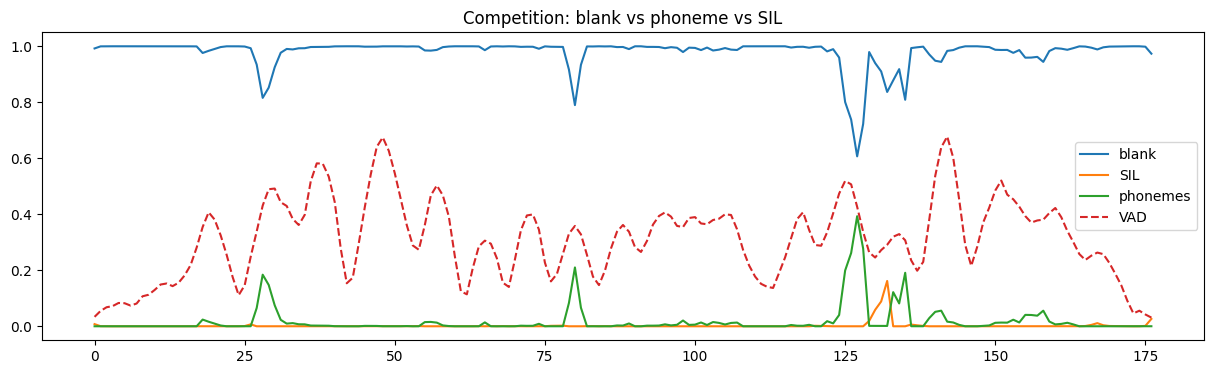

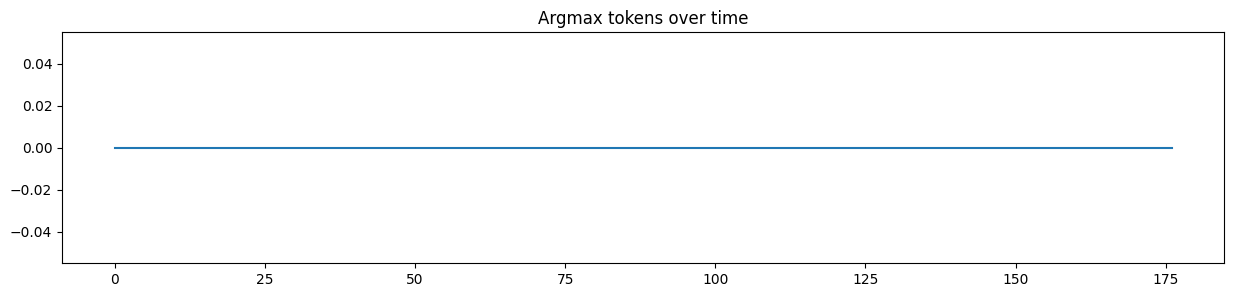

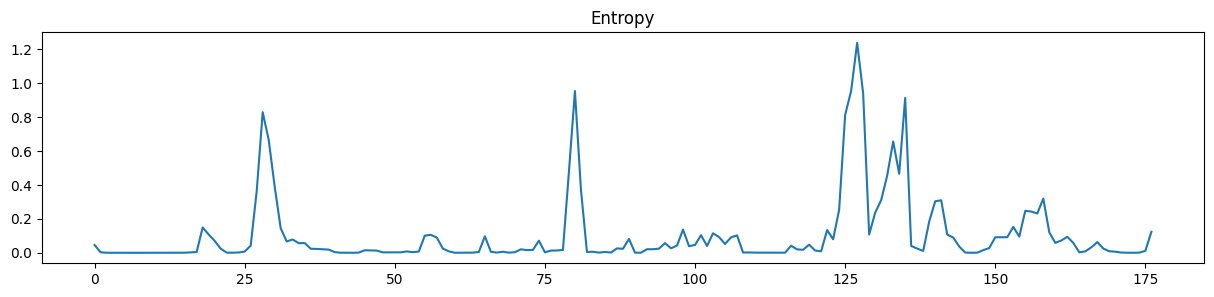

In [70]:
logits = forward_model(audio, processor, model, device)

T_model = logits.shape[1]

vad = prepare_vad(vad_np, T_model, device)

tokenizer = processor.tokenizer
blank_id = tokenizer.pad_token_id

sil_id = tokenizer.convert_tokens_to_ids("SIL")

logits = logits.transpose(1, 2)
logits = F.avg_pool1d(logits, kernel_size=7, stride=1, padding=3)
logits = logits.transpose(1, 2)
logits_vad = apply_vad_constraints(
    logits,
    vad,
    blank_id=blank_id,
    sil_id=sil_id,
    alpha = 8.0,   # boost SIL HARD
beta  = 6.0,   # suppress phonemes HARD
gamma = 4.0, 
    threshold=0.3
)

# Decode
path = viterbi_decode(logits_vad)

# Build id → token map
id2token = {i: t for t, i in tokenizer.get_vocab().items()}

segments = extract_segments(path, id2token, blank_id=blank_id)

# Analysis plots
plot_analysis(logits_vad, vad, blank_id, sil_id)